# Baseline Modeling (7개 모델 비교)

데이터 로드 → 전처리(클리닝/이상치/메타피처/집계/스케일링) → 7개 모델 Baseline 비교 및 Feature Importance

**목적**: 다양한 모델을 기본 파라미터로 돌려 RMSE를 한눈에 비교하고, 유망 모델을 선별.

**EDA 반영 사항**:
- 고상관 피처 제거 (|r|>0.95), 결측 indicator 추가
- 로트별 WT 집계 통계 + 웨이퍼 패턴 메타 피처
- 집계 함수 확장: mean+std+min+max+range+median

**모델**: LightGBM, XGBoost, CatBoost, RandomForest(cuML GPU), RidgeCV, LassoCV, ElasticNetCV

## 1. 환경 설정 및 데이터 로드

In [1]:
import os, sys

try:
    import google.colab
    if not os.path.exists("/content/project/setup.py"):
        os.system("pip install -q gdown")
        os.system("gdown --id 1AD4PDBnDVjp-LSna6puB7qLnpBqB7j_I -O /content/code.zip")
        os.system("unzip -qo /content/code.zip -d /content/project")
        os.makedirs("/content/project/0_data", exist_ok=True)
        os.system("gdown --id 1yOUo0_wPLcuZBSJIK592b00YkSIlk4zO -O /content/project/0_data/dataset.zip")
        os.system("unzip -qo /content/project/0_data/dataset.zip -d /content/project/0_data")
        os.remove("/content/project/0_data/dataset.zip")
    if not os.path.exists("/content/project/2_preprocessing/cleaning.py"):
        os.system("gdown --id 1Rh0ByOS4Gama8XHuvY7KkOHo278H9YLr -O /content/preprocessing.zip")
        os.system("unzip -qo /content/preprocessing.zip -d /content/project")
    sys.path.insert(0, "/content/project")
    %run /content/project/setup.py
except ImportError:
    %run ../setup.py

# ─── 공통 import ───
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from tqdm.auto import tqdm

# 트리 모델
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
# RandomForest: cuML GPU 가속 (fallback → sklearn CPU)
try:
    from cuml.ensemble import RandomForestRegressor
    CUML_RF = True
except ImportError:
    from sklearn.ensemble import RandomForestRegressor
    CUML_RF = False

# 선형 모델 (CV 내장 = alpha 자동 탐색)
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

# 스케일링 / 평가
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error

# 프로젝트 utils
from utils.config import PROJECT_ROOT, SEED, TARGET_COL
from utils.data import load_all, get_feat_cols, split_xs
from utils.aggregate import merge_with_target
from utils.evaluate import evaluate, postprocess, compare_models

# 전처리 모듈
sys.path.insert(0, os.path.join(PROJECT_ROOT, "2_preprocessing"))
from cleaning import run_cleaning
from outlier import run_outlier_treatment
from meta_features import run_meta_features
from aggregation import run_aggregation

# ─── 데이터 로드 ───
xs, ys = load_all()
feat_cols = get_feat_cols(xs)
xs_dict = split_xs(xs)
ys_train = ys["train"]
ys_val = ys["validation"]

setup 완료
Xs: (174980, 1091)  |  Ys: train=26,247, val=8,749, test=8,749


## 2. 전처리 파이프라인 (클리닝 → 이상치 → 메타피처 → 집계)

EDA 결과 반영:
- **클리닝**: 상수/극저분산/고결측/중복 + **고상관(|r|>0.95) 제거** + 결측 indicator
- **이상치**: Winsorization (1%/99%)
- **메타 피처**: 로트별 WT 집계 통계 + 웨이퍼 패턴 One-Hot + die 좌표
- **집계**: mean + std + min + max + **range + median** (EDA Phase 26)

In [2]:
# --- Step 1: 클리닝 (상수/고결측/중복/고상관 제거 + 결측 imputation + indicator) ---
xs_train, xs_val, xs_test, clean_cols, clean_report = run_cleaning(
    xs, feat_cols, xs_dict,
    const_threshold=1e-6,      # std가 이 값 이하인 feature 제거
    missing_threshold=0.75,     # 결측률이 이 비율 이상인 feature 제거
    remove_duplicates=True,    # 값이 완전히 동일한 중복 컬럼 제거
    corr_threshold=0.95,       # [NEW] |r|>0.95 고상관 쌍에서 한쪽 제거 (EDA Phase 11)
    add_indicator=True,        # [NEW] 결측률 1%+ feature에 _missing indicator 추가 (EDA Phase 5)
    indicator_threshold=0.01,  # indicator 추가 기준 (결측률 >= 1%)
)

클리닝 파이프라인 시작
원본 feature 수: 1087
[상수/극저분산 제거] threshold=1e-06
  제거: 105개, 잔여: 982개
    컬럼: 1087 → 982 (105개 제거)
    DataFrame: (104988, 986)

[고결측 제거] threshold=75%
  제거: 3개, 잔여: 979개
    컬럼: 982 → 979 (3개 제거)
    DataFrame: (104988, 983)

[중복 컬럼 제거] sample_n=5000
  제거: 26개, 잔여: 953개
    컬럼: 979 → 953 (26개 제거)
    DataFrame: (104988, 957)

[고상관 제거] threshold=0.95
  제거: 214개, 잔여: 739개
    컬럼: 953 → 739 (214개 제거)
    DataFrame: (104988, 743)

[결측 indicator] 13개 컬럼 추가 (결측률 >= 1%)
[결측 imputation] train median 기준
  imputation 후 잔여 결측: 0

클리닝 완료: 1087 → 739 features (348개 제거)
  + indicator 컬럼: 13개 → 총 752개
  train: (104988, 756)
  val:   (34996, 756)
  test:  (34996, 756)


In [3]:
# --- Step 2: 이상치 처리 (Winsorization) ---
xs_train, xs_val, xs_test, outlier_report = run_outlier_treatment(
    xs_train, xs_val, xs_test, clean_cols,
    lower_pct=0.01,   # 하위 분위수 경계 (이 미만 값을 클리핑)
    upper_pct=0.99,   # 상위 분위수 경계 (이 초과 값을 클리핑)
)

이상치 처리 파이프라인 시작
[이상치 탐지] IQR × 1.5
  이상치 > 5%: 132개
  이상치 > 10%: 67개
[Winsorization] lower=1%, upper=99%
  적용 feature: 752개
[이상치 탐지] IQR × 1.5
  이상치 > 5%: 131개
  이상치 > 10%: 67개

이상치 처리 완료
  이상치 >5%  feature: 132 → 131 (1개 감소)
  이상치 >10% feature: 67 → 67 (0개 감소)
  train: (104988, 756)


In [4]:
# --- Step 2.5: 메타 피처 생성 (로트 통계 + 웨이퍼 패턴 + die 좌표) ---
# EDA Phase 19: 로트 간 health 차이 p=1.69e-242 → 가장 강력한 메타 피처
# EDA Phase 18-1: 웨이퍼 패턴별 health 유의 차이
# 주의: lot_stats=True → feat_cols × 2(mean,std) = ~1,900개 메타 컬럼 추가

# clean_cols에서 indicator 컬럼 제외한 WT feature만 추출 (lot 통계 계산용)
wt_feat_cols = [c for c in clean_cols if not c.endswith("_missing")]

xs_train, xs_val, xs_test, meta_cols = run_meta_features(
    xs_train, xs_val, xs_test,
    feat_cols=wt_feat_cols,        # WT feature만 (indicator 제외)
    ys_train=ys_train,
    lot_stats=True,                # 로트별 WT 집계 통계
    lot_agg_funcs=["mean", "std"], # 로트별 평균 + 표준편차
    wafer_pattern=True,            # 웨이퍼 패턴 One-Hot
    die_coords=True,               # die_x, die_y 좌표
)

# 집계에 넘길 전체 피처 = WT feature + indicator + 메타 피처
all_feat_cols = clean_cols + meta_cols
print(f"\n집계 대상 총 피처: {len(all_feat_cols)}개 "
      f"(WT: {len(wt_feat_cols)}, indicator: {len(clean_cols)-len(wt_feat_cols)}, "
      f"meta: {len(meta_cols)})")

메타 피처 생성 시작
[run_wf_xy 파싱] lot: 28개, wafer: 25개, die_x: 12~66, die_y: 11~32
[run_wf_xy 파싱] lot: 28개, wafer: 25개, die_x: 13~66, die_y: 11~32
[run_wf_xy 파싱] lot: 28개, wafer: 25개, die_x: 12~66, die_y: 11~32
[로트 메타 피처] 1478개 컬럼 추가 (feat × agg = 739 × 2)
  train lot: 28개, val lot: 28개, test lot: 28개

[웨이퍼 패턴] train 웨이퍼 432장 분류:
  Edge: 219장 (50.7%)
  Random: 189장 (43.8%)
  None: 24장 (5.6%)
  One-Hot 컬럼: ['wf_pattern_Edge', 'wf_pattern_None', 'wf_pattern_Random']

[die 좌표 피처] ['die_x', 'die_y'] 확인 완료

메타 피처 생성 완료: 1483개 컬럼 추가
  train: (104988, 2239)
  val:   (34996, 2239)
  test:  (34996, 2239)

집계 대상 총 피처: 2235개 (WT: 739, indicator: 13, meta: 1483)


In [5]:
# --- Step 3: Die → Unit 집계 ---
# EDA Phase 26: median이 max|r| 1위(0.0377), range도 유용 → 기본값에 포함
unit_train, unit_val, unit_test, unit_feat_cols = run_aggregation(
    xs_train, xs_val, xs_test, all_feat_cols,
    agg_funcs=["mean"], # None        # 기본값: mean+std+min+max+range+median
    use_position_pivot=False,                   # True면 position별 피벗 feature도 추가
    save_csv=False,                             # baseline에서는 CSV 저장 안 함
)

Die → Unit 집계 시작
  agg_funcs: ['mean']
  position_pivot: False
집계 완료: 26,247 units × 2,235 features (agg: ['mean'])
집계 완료: 8,749 units × 2,235 features (agg: ['mean'])
집계 완료: 8,749 units × 2,235 features (agg: ['mean'])

집계 결과:
  train: (26247, 2235)
  val:   (8749, 2235)
  test:  (8749, 2235)
  feature 수: 2235


## 3. Target Merge 및 학습 데이터 준비

In [6]:
# Target merge (train / val / test)
X_train, y_train = merge_with_target(unit_train, split="train")
X_val, y_val = merge_with_target(unit_val, split="validation")
X_test, y_test = merge_with_target(unit_test, split="test")

# NaN 확인
assert X_train.isnull().sum().sum() == 0, "X_train에 NaN 존재!"
assert X_val.isnull().sum().sum() == 0, "X_val에 NaN 존재!"
assert X_test.isnull().sum().sum() == 0, "X_test에 NaN 존재!"

# RobustScaler (선형/딥러닝 모델용이지만, 트리 모델에 영향 없으므로 1벌로 통일)
scaler = RobustScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_s = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"\ny_train: mean={y_train.mean():.6f}, zero={(y_train==0).mean()*100:.1f}%")
print(f"y_val:   mean={y_val.mean():.6f}, zero={(y_val==0).mean()*100:.1f}%")
print(f"y_test:  mean={y_test.mean():.6f}, zero={(y_test==0).mean()*100:.1f}%")

# 단순 baseline (비교 기준선)
print(f"\n--- 단순 Baseline ---")
evaluate(y_val, np.zeros(len(y_val)), label="all-zero")
evaluate(y_val, np.full(len(y_val), y_train.mean()), label="train-mean")

Merge (train): X=(26247, 2235), y=(26247,), y_mean=0.002515
Merge (validation): X=(8749, 2235), y=(8749,), y_mean=0.002505
Merge (test): X=(8749, 2235), y=(8749,), y_mean=0.002610

y_train: mean=0.002515, zero=70.8%
y_val:   mean=0.002505, zero=70.8%
y_test:  mean=0.002610, zero=70.8%

--- 단순 Baseline ---
[all-zero] RMSE = 0.006331  (n=8,749, zero=6,194(70.8%))
[train-mean] RMSE = 0.005814  (n=8,749, zero=6,194(70.8%))


0.00581430473855135

In [7]:
# 임시 --------------------------------------------------------------------------
# ===== 1/10 샘플링 (실험용) =====
SAMPLE_FRAC = 1.0
sample_idx = X_train_s.sample(frac=SAMPLE_FRAC, random_state=SEED).index
X_train_s = X_train_s.loc[sample_idx].reset_index(drop=True)
y_train = y_train.loc[sample_idx].reset_index(drop=True)
print(f"샘플링: {len(sample_idx)} → {len(X_train_s)} ({SAMPLE_FRAC*100:.0f}%)")

샘플링: 26247 → 26247 (100%)


## 4. 7개 모델 Baseline 비교 (Train → Val/Test 평가)

트리 4개 + 선형 3개를 **기본 파라미터**로 학습하여 Val/Test RMSE를 비교

- **학습**: Train set으로 학습 (LightGBM/XGBoost/CatBoost는 Val set으로 early stopping)
- **선형 모델**: RidgeCV/LassoCV/ElasticNetCV로 alpha 자동 탐색 (공정한 디폴트)
- **RandomForest**: cuML GPU 가속 (미설치 시 sklearn CPU fallback)

In [ ]:
# ─── 7개 모델 정의 (튜닝 파라미터 적용) ───

_rf_params = dict(
    n_estimators=500,
    max_depth=20,
    min_samples_split=18,
    min_samples_leaf=43,
    max_features=0.25306320182735925,
    random_state=SEED,
)

# cuML일 때만 n_bins 사용 가능
if CUML_RF:
    _rf_params["n_bins"] = 212
else:
    _rf_params["n_jobs"] = -1  # sklearn용


models = {
    "LightGBM": lgb.LGBMRegressor(
        iterations=10000,
        learning_rate=0.012457466004205876,
        num_leaves=49,
        max_depth=7,
        min_child_samples=245,
        subsample=0.7591420347752385,
        colsample_bytree=0.10415361830684666,
        reg_alpha=0.02321388377387803,
        reg_lambda=0.14505131037326144,
        min_split_gain=0.00010132317378668888,
        path_smooth=20.64149821542759,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1,
    ),

    "XGBoost": xgb.XGBRegressor(
        iterations=10000,
        learning_rate=0.011451990681852282,
        max_depth=5,
        min_child_weight=196,
        subsample=0.6218331639891203,
        colsample_bytree=0.2145687047951325,
        colsample_bylevel=0.4790838112716643,
        gamma=0.00015497790886228978,
        max_delta_step=1.2861321519634659,
        reg_alpha=0.03559731452898653,
        reg_lambda=6.284480349087426,
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
        early_stopping_rounds=50,
    ),

    "CatBoost": CatBoostRegressor(
        iterations=10000,
        bootstrap_type="Bernoulli",
        learning_rate=0.028086352214044857,
        depth=6,
        l2_leaf_reg=11.569573158250058,
        min_data_in_leaf=133,
        random_strength=0.11220172534317333,
        subsample=0.8376570943201853,
        random_seed=SEED,
        verbose=0,
        early_stopping_rounds=50,
    ),

    "RandomForest": RandomForestRegressor(**_rf_params),
    # "RidgeCV": RidgeCV(
    #     alphas=np.logspace(-6, 6, 50),
    # ),
    # "LassoCV": LassoCV(
    #     alphas=np.logspace(-6, 2, 50), max_iter=5000, random_state=SEED, n_jobs=-1,
    # ),
    # "ElasticNetCV": ElasticNetCV(
    #     alphas=np.logspace(-6, 2, 50), l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
    #     max_iter=5000, random_state=SEED, n_jobs=-1,
    # ),
}

print(f"모델 {len(models)}개 정의 완료")
if CUML_RF:
    print("  → RandomForest: cuML GPU 가속")
else:
    print("  → RandomForest: sklearn CPU")

모델 4개 정의 완료
  → RandomForest: sklearn CPU


In [9]:
# ─── 7개 모델: Train 학습 → Val/Test 평가 ───
results = {}
trained_models = {}

pbar = tqdm(models.items(), desc="모델 학습", unit="model")
for name, model in pbar:
    pbar.set_postfix_str(name)

    # 학습 (LightGBM/XGBoost/CatBoost는 val로 early stopping)
    if name == "LightGBM":
        model.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
    elif name == "XGBoost":
        model.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)], verbose=False)
    elif name == "CatBoost":
        model.fit(X_train_s, y_train, eval_set=(X_val_s, y_val))
    else:
        model.fit(X_train_s, y_train)

    # Val / Test 예측 + 평가
    pred_val = postprocess(model.predict(X_val_s))
    pred_test = postprocess(model.predict(X_test_s))
    val_rmse = evaluate(y_val, pred_val, label=f"{name} (val)")
    test_rmse = evaluate(y_test, pred_test, label=f"{name} (test)")

    results[name] = {
        "val_pred": pred_val, "test_pred": pred_test,
        "val_rmse": val_rmse, "test_rmse": test_rmse,
    }
    trained_models[name] = model

    # 선형 모델은 선택된 alpha 출력
    if hasattr(model, 'alpha_'):
        info = f"  → best alpha={model.alpha_:.6g}"
        if hasattr(model, 'l1_ratio_'):
            info += f", l1_ratio={model.l1_ratio_:.2f}"
        print(info)

print(f"\n{'='*50}")
print(f"{len(results)}개 모델 학습 완료")

모델 학습:   0%|          | 0/4 [00:00<?, ?model/s]

[LightGBM (val)] RMSE = 0.005747  (n=8,749, zero=6,194(70.8%))
[LightGBM (test)] RMSE = 0.008442  (n=8,749, zero=6,194(70.8%))
[XGBoost (val)] RMSE = 0.005753  (n=8,749, zero=6,194(70.8%))
[XGBoost (test)] RMSE = 0.008447  (n=8,749, zero=6,194(70.8%))
[CatBoost (val)] RMSE = 0.005766  (n=8,749, zero=6,194(70.8%))
[CatBoost (test)] RMSE = 0.008456  (n=8,749, zero=6,194(70.8%))
[RandomForest (val)] RMSE = 0.005738  (n=8,749, zero=6,194(70.8%))
[RandomForest (test)] RMSE = 0.008432  (n=8,749, zero=6,194(70.8%))

4개 모델 학습 완료


In [10]:
# ─── RMSE 비교표 (Val / Test) ───
comparison = pd.DataFrame([
    {
        "Model": name,
        "Val RMSE": r["val_rmse"],
        "Test RMSE": r["test_rmse"],
    }
    for name, r in results.items()
]).sort_values("Val RMSE").reset_index(drop=True)
comparison.index += 1

comparison

,Model,Val RMSE,Test RMSE
1,RandomForest,0.005738,0.008432
2,LightGBM,0.005747,0.008442
3,XGBoost,0.005753,0.008447
4,CatBoost,0.005766,0.008456


## 5. Feature Importance (트리 모델 4종 비교)

LightGBM, XGBoost, CatBoost, RandomForest의 feature importance를 비교하여 공통 핵심 피처를 파악

In [11]:
# ─── 트리 모델 4종 Feature Importance 추출 ───
tree_models = ["LightGBM", "XGBoost", "CatBoost", "RandomForest"]
importance_dict = {}

for name in tree_models:
    model = trained_models[name]
    imp = model.feature_importances_
    df = pd.DataFrame({"feature": X_train_s.columns, "importance": imp})
    # 정규화 (모델 간 스케일 통일)
    df["importance_norm"] = df["importance"] / df["importance"].sum()
    df = df.sort_values("importance", ascending=False).reset_index(drop=True)
    df.index += 1
    # 원본 feature명 추출 (X123_mean → X123)
    df["original_feature"] = df["feature"].str.replace(r"_(mean|std|min|max|range|median|skew)$", "", regex=True)
    df["agg_type"] = df["feature"].str.extract(r"_(mean|std|min|max|range|median|skew)$")[0]
    importance_dict[name] = df

# 모델별 Top 10 출력
for name in tree_models:
    df = importance_dict[name]
    print(f"\n{'='*50}")
    print(f"[{name}] Feature Importance Top 10")
    print(df[["feature", "importance", "importance_norm"]].head(10).to_string())
    zero_imp = (df["importance"] == 0).sum()
    print(f"중요도 = 0: {zero_imp}개 / {len(df)}개 ({zero_imp/len(df)*100:.1f}%)")


[LightGBM] Feature Importance Top 10
                 feature  importance  importance_norm
1              X718_mean          51         0.020425
2             X1083_mean          38         0.015218
3   wf_pattern_None_mean          29         0.011614
4              X161_mean          28         0.011213
5             X1070_mean          28         0.011213
6             X1001_mean          24         0.009612
7              X831_mean          24         0.009612
8              X851_mean          23         0.009211
9              X726_mean          23         0.009211
10              X19_mean          21         0.008410
중요도 = 0: 1496개 / 2235개 (66.9%)

[XGBoost] Feature Importance Top 10
               feature  importance  importance_norm
1   lot_mean_X749_mean    0.010869         0.010869
2   lot_mean_X653_mean    0.010263         0.010263
3    lot_std_X464_mean    0.010175         0.010175
4             X30_mean    0.009726         0.009726
5    lot_std_X344_mean    0.009401      

원본 Feature 기준 중요도 Top 20 (4종 트리 모델 평균)
                  LightGBM   XGBoost  CatBoost  RandomForest  mean_importance
original_feature                                                             
X79               0.002002  0.006878  0.314477      0.012297         0.083914
X718              0.020425  0.005146  0.046863      0.029284         0.025429
X1007             0.002002  0.003449  0.057519      0.030240         0.023303
X725              0.002803  0.006778  0.032555      0.034306         0.019111
lot_mean_X1083    0.002002  0.004668  0.051661      0.011939         0.017568
wf_pattern_None   0.011614  0.003481  0.037306      0.014623         0.016756
lot_mean_X514     0.000801  0.004145  0.048518      0.005440         0.014726
X1023             0.004005  0.005209  0.039506      0.001875         0.012649
lot_std_X271      0.000400  0.006298  0.036823      0.000540         0.011015
X28               0.000400  0.006687  0.033926      0.001815         0.010707
X336              0.00080

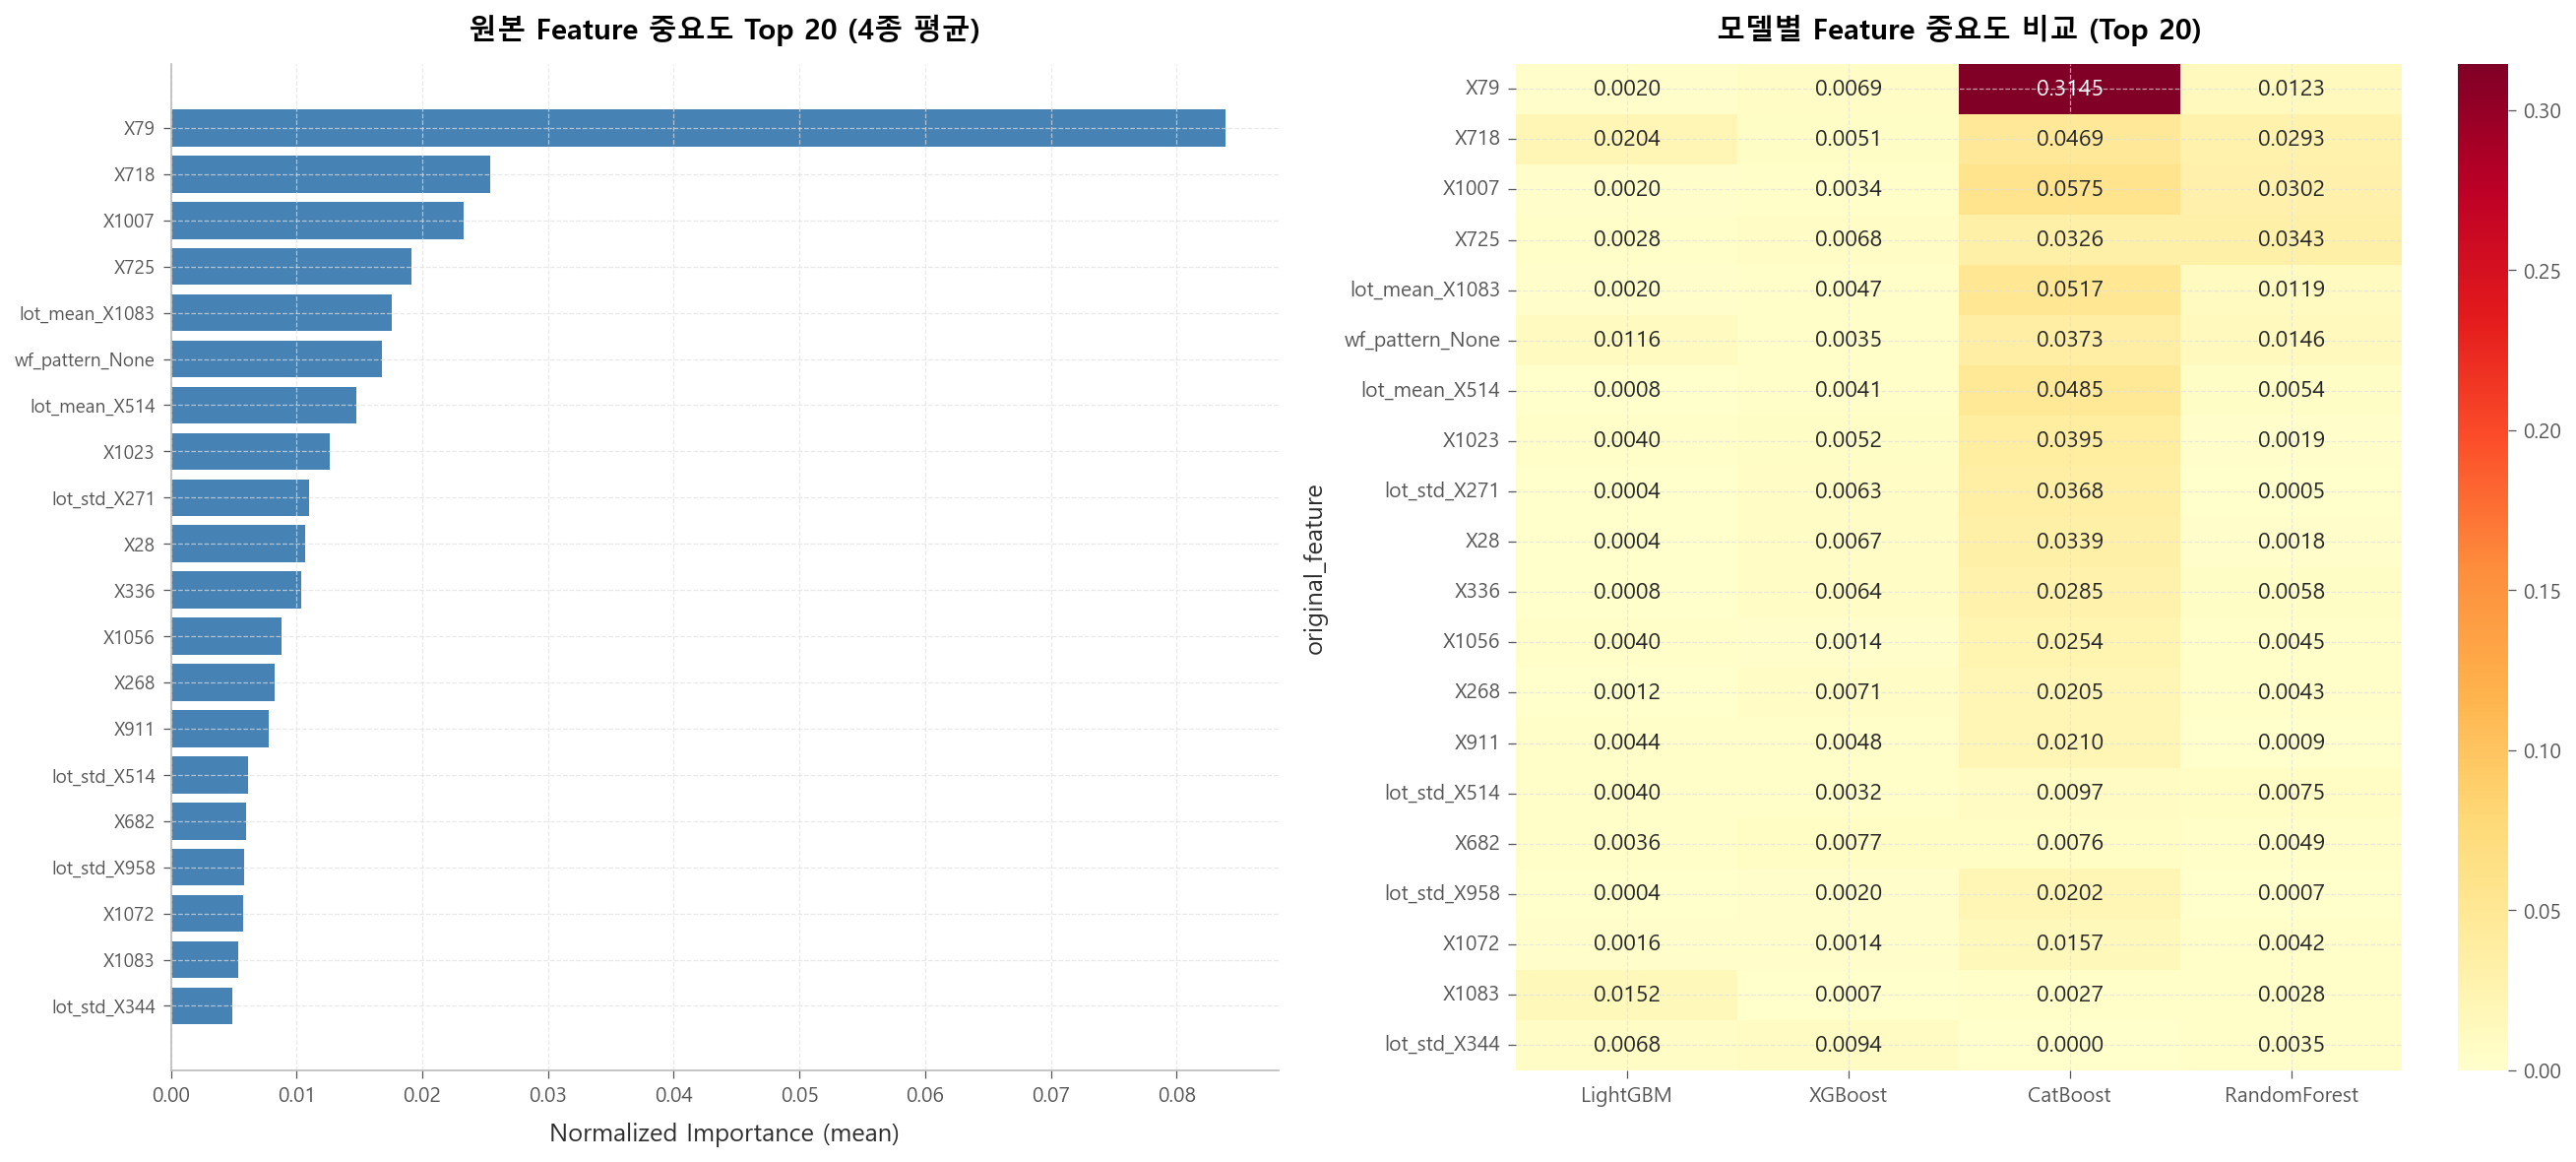

In [12]:
# ─── 트리 모델 공통 중요 feature 분석 (원본 X번호 기준) ───
# 각 모델에서 원본 feature별 정규화 중요도 합산 → 4종 트리 모델 평균
orig_imp_per_model = {}
for name in tree_models:
    df = importance_dict[name]
    orig = df.groupby("original_feature")["importance_norm"].sum()
    orig_imp_per_model[name] = orig

orig_imp_all = pd.DataFrame(orig_imp_per_model)
orig_imp_all["mean_importance"] = orig_imp_all.mean(axis=1)
orig_imp_all = orig_imp_all.sort_values("mean_importance", ascending=False)

print("=" * 70)
print("원본 Feature 기준 중요도 Top 20 (4종 트리 모델 평균)")
print("=" * 70)
print(orig_imp_all.head(20).round(6).to_string())

# 시각화: 모델별 Top 20 비교
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 좌: 4종 트리 모델 평균 Top 20
top20 = orig_imp_all.head(20)
axes[0].barh(range(len(top20)), top20["mean_importance"], color="steelblue")
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20.index, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_title("원본 Feature 중요도 Top 20 (4종 평균)")
axes[0].set_xlabel("Normalized Importance (mean)")

# 우: 모델별 Top 20 히트맵
top20_models = orig_imp_all.head(20)[tree_models]
import seaborn as sns
sns.heatmap(top20_models, annot=True, fmt=".4f", cmap="YlOrRd",
            ax=axes[1], xticklabels=True, yticklabels=True)
axes[1].set_title("모델별 Feature 중요도 비교 (Top 20)")

plt.tight_layout()
plt.show()

## 6. 예측 분포 확인

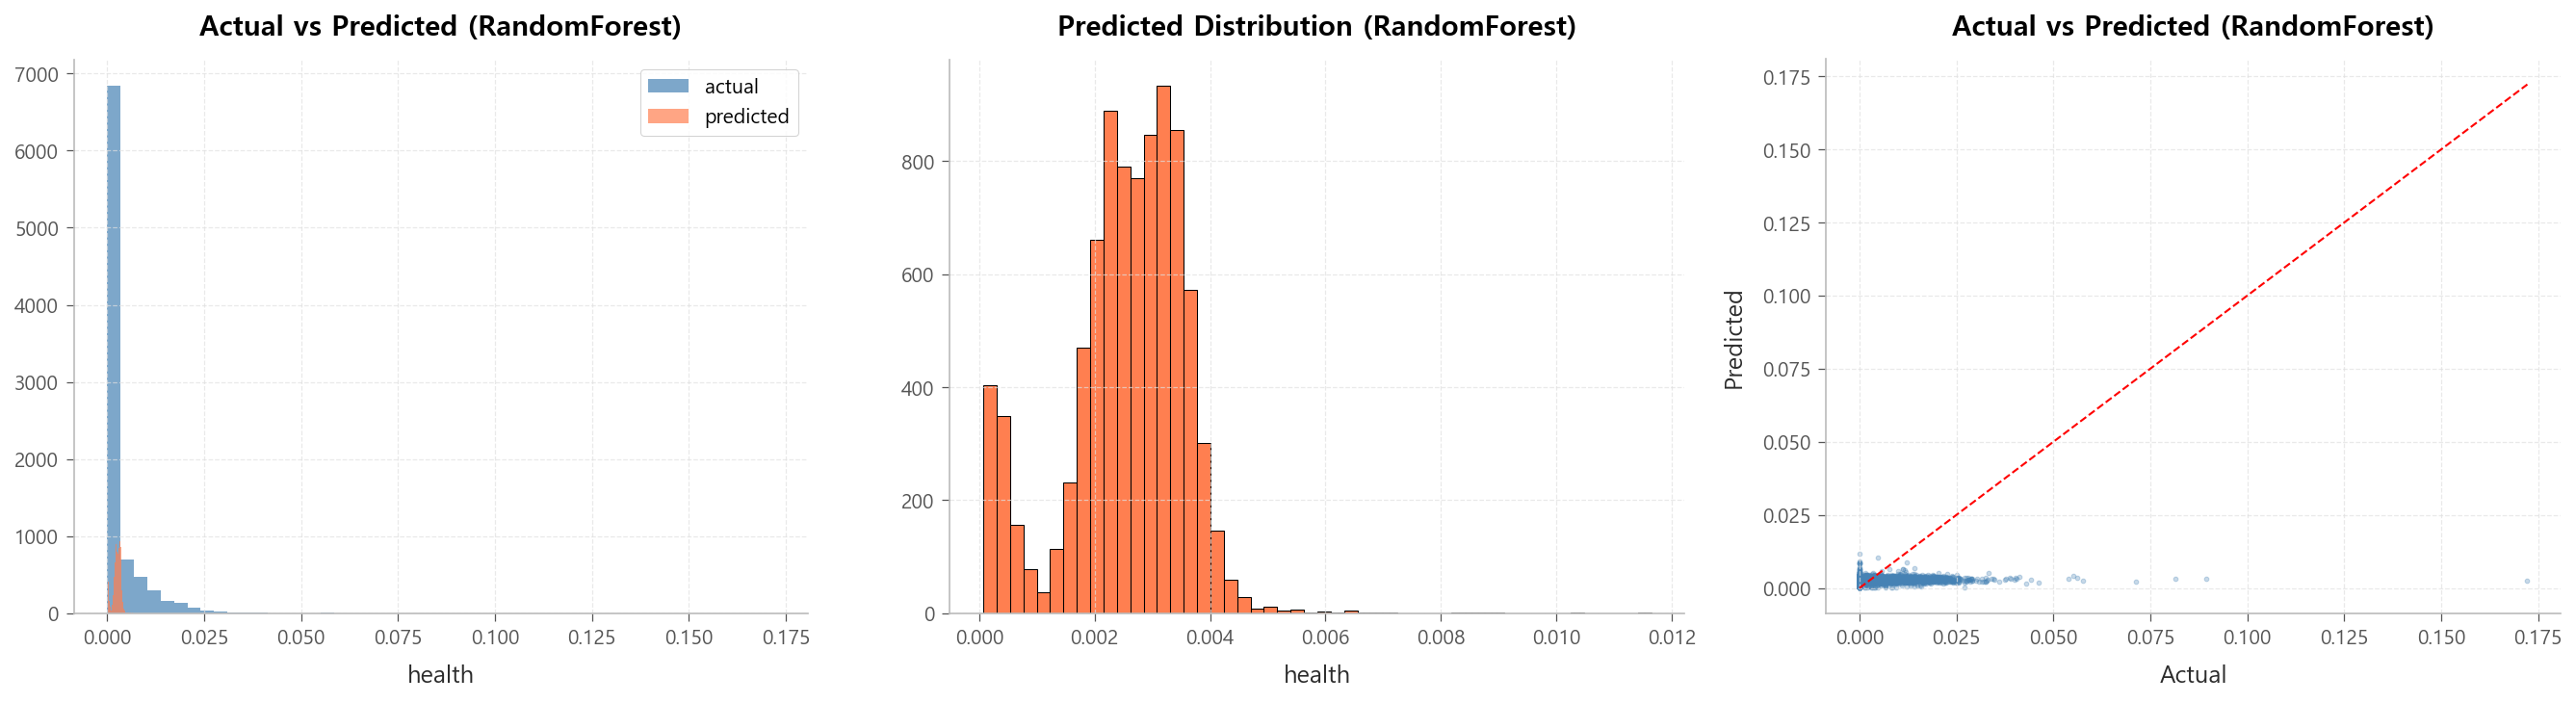

[RandomForest] 예측값 통계:
  min=0.000069, max=0.011645, mean=0.002542
  예측 0 비율: 0.0%


In [13]:
# ─── 최고 모델의 예측 분포 확인 ───
best_model_name = comparison.iloc[0]["Model"]
best_pred_val = results[best_model_name]["val_pred"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 실제 vs 예측 히스토그램
axes[0].hist(y_val, bins=50, alpha=0.7, label="actual", color="steelblue")
axes[0].hist(best_pred_val, bins=50, alpha=0.7, label="predicted", color="coral")
axes[0].set_title(f"Actual vs Predicted ({best_model_name})")
axes[0].legend()
axes[0].set_xlabel(TARGET_COL)

# 예측값 분포 확대
axes[1].hist(best_pred_val, bins=50, color="coral", edgecolor="black")
axes[1].set_title(f"Predicted Distribution ({best_model_name})")
axes[1].set_xlabel(TARGET_COL)

# Scatter
axes[2].scatter(y_val, best_pred_val, alpha=0.3, s=5, color="steelblue")
axes[2].plot([0, y_val.max()], [0, y_val.max()], "r--", linewidth=1)
axes[2].set_xlabel("Actual")
axes[2].set_ylabel("Predicted")
axes[2].set_title(f"Actual vs Predicted ({best_model_name})")

plt.tight_layout()
plt.show()

print(f"[{best_model_name}] 예측값 통계:")
print(f"  min={best_pred_val.min():.6f}, max={best_pred_val.max():.6f}, mean={best_pred_val.mean():.6f}")
print(f"  예측 0 비율: {(best_pred_val == 0).mean()*100:.1f}%")